# README
This notebook is calculating the flow rates of the pumps based on data taken and saved under the logs directory

In [14]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path


def find_project_root(start=None):
    path = Path.cwd() if start is None else Path(start)

    for parent in [path] + list(path.parents):
        if (parent / "README.md").exists():
            return parent
        if (parent / ".git").exists():
            return parent

    raise RuntimeError("Could not find project root")

ROOT_DIR = find_project_root()

LOG_DIR = ROOT_DIR / 'logs'


In [42]:
def filename_data(test_name):
    """This function takes the name/description of a test and returns the corresponding csv file"""
    for file in LOG_DIR.iterdir():
        with open(file,'r') as f: 
            meta_line = f.readline().strip()
            contents = meta_line.split(',')[1:]
            if len(contents)==0:
                print (meta_line)
                raise
            if "yes" in contents or "no" in contents:
                if test_name=="inlet_choked yes" and "yes" in contents:
                    return file
                if test_name=="inlet_choked no" and "no" in contents:
                    return file
            elif test_name == contents[-1]:
                return file



## Flow rate of the compressor alone

In [48]:
test_header = 'only_compressor_manual_outlet'
file_name_test = filename_data(test_header)
df = pd.read_csv(file_name_test, header=1)
df.columns

Index(['DATA', 'ts_ms', 'diaphragm_pct', 'piston_pct', 'mpx_pressure_hPa',
       'bmp_temp_C', 'bmp_pressure_hPa', 'dht_temp_C', 'dht_humidity'],
      dtype='str')

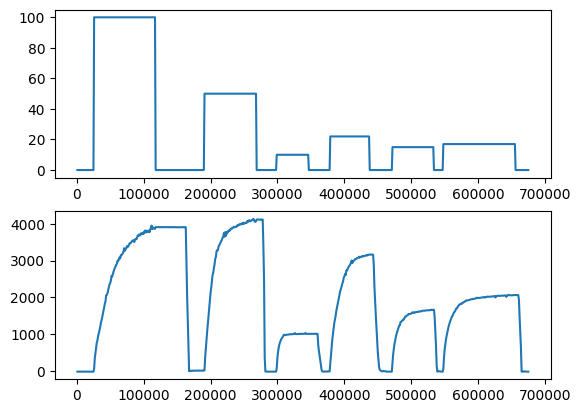

In [50]:
fig,ax = plt.subplots(2,1)
ax[0].plot(df["ts_ms"], df["piston_pct"])
ax[1].plot(df["ts_ms"], df['mpx_pressure_hPa'])